# 讀取資料集
從Kaggle直接讀取資料集，初始欄位有  
Unnamed: 放id、Lyric、genre

訓練集500000筆、測試集50000筆  
用隨機抽取5000跟500來實驗，已經有確定每次抽到的會是固定的了  

有Plot一張圖來看資料分布，看起來頗平衡 讚讚

In [ ]:
import kagglehub
import os

# 下載資料集
path = kagglehub.dataset_download("d3stron/english-music-lyrics-5-genres-500k")

# 列出下載的資料夾內容
print("Dataset files:", os.listdir(path))


Dataset files: ['cleaned_train_lyrics.csv', 'cleaned_test_lyrics.csv']


In [ ]:
import pandas as pd

# 讀取訓練資料
train_csv = os.path.join(path, "cleaned_train_lyrics.csv")
test_csv = os.path.join(path, "cleaned_test_lyrics.csv")

# 使用 pandas 讀取 CSV 檔案
df_train = pd.read_csv(train_csv)
df_test = pd.read_csv(test_csv)

# 顯示前幾筆數據
print("Train dataset preview:")
print(df_train.head())

Train dataset preview:
   Unnamed: 0                                              Lyric  genre
0           0  See me, ancient one! Dismal Tuat, Nergal unsaf...  Metal
1           1  Feels like Im covered in lies so turn off the ...  Metal
2           2  Works of art, painted black Magniloquent, blee...  Metal
3           3  Into the cage like an animal You must survive ...  Metal
4           4  Paralysed in pleasure I hear you call Lost my ...  Metal


In [ ]:
# 查看訓練集和測試集的長度
train_length = len(df_train)
test_length = len(df_test)

print(f"Training dataset length: {train_length}")
print(f"Test dataset length: {test_length}")


Training dataset length: 500000
Test dataset length: 50000


Random the dataset, and choose 5000 for training, 500 for testing.  
Also make sure that the subset will be the same in each time.

In [ ]:
# 讀取 CSV
df_train = pd.read_csv(train_csv)
df_test = pd.read_csv(test_csv)

# 打亂數據並取樣（確保 random_state 固定）
df_train = df_train.sample(frac=1, random_state=77).iloc[:5000]  # 取 5000 筆訓練資料
df_test = df_test.sample(frac=1, random_state=77).iloc[:500]  # 取 500 筆測試資料

# 顯示數據集大小
print(f"New Training Dataset Size: {len(df_train)}")
print(f"New Test Dataset Size: {len(df_test)}")

df_train = df_train.reset_index(drop=True)  # 重置索引，確保每次執行時索引順序不變
df_test = df_test.reset_index(drop=True)

print(df_train.head(10))  # 查看前10筆是否每次都一樣
print(df_test.head(10))


New Training Dataset Size: 5000
New Test Dataset Size: 500
   Unnamed: 0                                              Lyric    genre
0      448760  search cost long search lose everybody help pe...  country
1      479107  [Verse 1] Let me be the one to walk with you, ...  country
2      486799  [Verse 1] All the times Ive wasted All the thi...  country
3      494185  [Verse 1] Woodys Roundup Right here, evryday W...  country
4      468639  [Verse] The Iowa weather was 13 below I had co...  country
5      110400  reborn fight fold hand pain leave lifeless liv...     rock
6       33036  Calcinated scrotal sacs Boiling syphilitic cha...    Metal
7      380849  To ride on a Black winged Llama over desert In...      pop
8      262117  [Eunice] Im drowning, can you help me? help me...      rap
9      420572  Send me some lovin oh send it I pray How can I...  country
   Unnamed: 0                                              Lyric    genre
0       14364  [Chorus] I aint lookin for a free ride

<ipython-input-10-d7cb1a3fd648>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")


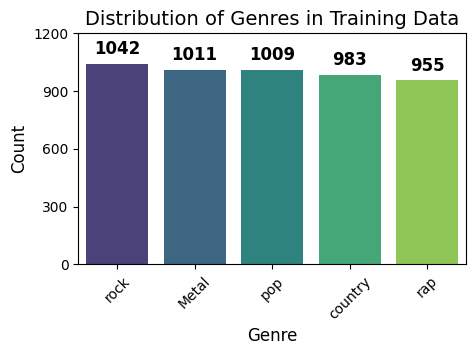

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 計算每個類別的數量
category_counts = df_train['genre'].value_counts()

# 設定圖表大小
plt.figure(figsize=(5, 3))

# 繪製長條圖
ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")

# 在長條圖上顯示數值
for i, count in enumerate(category_counts.values):
    ax.text(i, count + 50, str(count), ha='center', fontsize=12, fontweight='bold')

# 設定 y 軸刻度，每 300 為一格
max_count = category_counts.max()
plt.yticks(np.arange(0, max_count + 300, 300))

# 加標籤
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Genres in Training Data", fontsize=14)
plt.xticks(rotation=45)  # 旋轉 x 軸標籤，避免文字重疊

# 顯示圖表
plt.show()


  # Data pre-processing

有需要可以自己新增客製化的stop words  
全部轉小寫、去掉標點符號  
還有特別增加一行去除[]包裹的字（例如[verse]等等的不重要的注釋）  

In [ ]:
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

# 取得英文停用詞
stop_words = set(stopwords.words('english'))
print("NLTK Stopwords Loaded:", list(stop_words)[:10])  # 顯示部分停用詞


NLTK Stopwords Loaded: ['down', 'each', "aren't", "you've", 'up', "doesn't", 'any', 'won', "you're", 'that']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')



# 假設你已經下載了nltk的stopwords，並進行了詞幹提取
stop_words = set(stopwords.words('english'))

# 添加自定義停用詞
custom_stopwords = ['im']  # 這裡添加你自己的停用詞
stop_words.update(custom_stopwords)  # 合併自定義停用詞與nltk的停用詞

stemmer = PorterStemmer()

# 文字清理函數
def clean_text(text):

    # 去除[]包裹的字（例如歌詞中的注釋）
    text = re.sub(r'\[.*?\]', '', text)
    # 小寫轉換
    text = text.lower()
    # 去除標點符號
    text = re.sub(r'[^\w\s]', '', text)
    # 分詞
    words = word_tokenize(text)
    # 移除停用詞並進行詞幹提取
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

# 清理歌詞
df_train['cleaned_train_lyrics'] = df_train['Lyric'].apply(clean_text)
df_test['cleaned_test_lyrics'] = df_test['Lyric'].apply(clean_text)

# 顯示前幾筆清理後的歌詞
print("Cleaned Train dataset preview:")
print(df_train[['Lyric', 'cleaned_train_lyrics']].head())


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Cleaned Train dataset preview:
                                               Lyric  \
0  search cost long search lose everybody help pe...   
1  [Verse 1] Let me be the one to walk with you, ...   
2  [Verse 1] All the times Ive wasted All the thi...   
3  [Verse 1] Woodys Roundup Right here, evryday W...   
4  [Verse] The Iowa weather was 13 below I had co...   

                                cleaned_train_lyrics  
0  search cost long search lose everybodi help pe...  
1  let one walk oh oh oh want someon talk anyth m...  
2  time ive wast thing thought knew think think b...  
3  woodi roundup right evryday woodi roundup come...  
4  iowa weather 13 come de moin radio show awok e...  


In [ ]:
df_train

,Unnamed: 0,Lyric,genre,cleaned_train_lyrics
0,448760,search cost long search lose everybody help pe...,country,search cost long search lose everybodi help pe...
1,479107,"[Verse 1] Let me be the one to walk with you, ...",country,let one walk oh oh oh want someon talk anyth m...
2,486799,[Verse 1] All the times Ive wasted All the thi...,country,time ive wast thing thought knew think think b...
3,494185,"[Verse 1] Woodys Roundup Right here, evryday W...",country,woodi roundup right evryday woodi roundup come...
4,468639,[Verse] The Iowa weather was 13 below I had co...,country,iowa weather 13 come de moin radio show awok e...
...,...,...,...,...
4995,100507,"[Verse 1] The sun came out this morning, I was...",rock,sun came morn wide awak stumbl kitchen cut pie...
4996,54423,Slowly it starts to decay Softly the borders v...,Metal,slowli start decay softli border vanish enemi ...
4997,80575,Moonlight comes through the shades now Moonlig...,Metal,moonlight come shade moonlight come shade cut ...
4998,347633,"I am weak, but Thou art strong Jesus, keep me ...",pop,weak thou art strong jesu keep wrong ill satis...


<ipython-input-14-83e156f2bb46>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='genre', y='lyrics_length_bf', data=genre_stats, ax=axes[0], palette='Blues_d')
<ipython-input-14-83e156f2bb46>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='genre', y='unique_words_bf', data=genre_stats, ax=axes[1], palette='Greens_d')


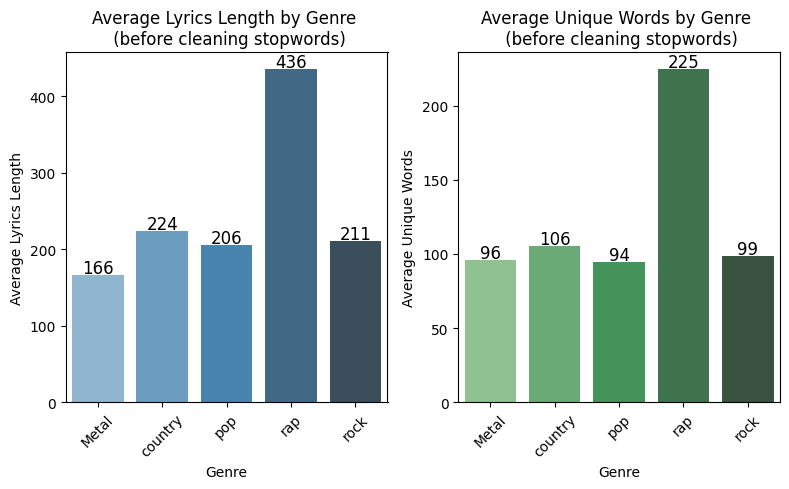

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 計算每首歌的歌詞長度（單詞數）
df_train['lyrics_length_bf'] = df_train['Lyric'].apply(lambda x: len(str(x).split()))

# 計算每首歌的獨特詞彙數量
df_train['unique_words_bf'] = df_train['Lyric'].apply(lambda x: len(set(str(x).split())))

# 按 genre 分組，計算平均歌詞長度與獨特詞彙數
genre_stats = df_train.groupby('genre')[['lyrics_length_bf', 'unique_words_bf']].mean().reset_index()

# 繪製兩張長條圖
fig, axes = plt.subplots(1, 2, figsize=(8, 5))  # 減小圖表的大小，讓兩個圖更寬鬆

# 歌詞長度統計
sns.barplot(x='genre', y='lyrics_length_bf', data=genre_stats, ax=axes[0], palette='Blues_d')
axes[0].set_title('Average Lyrics Length by Genre \n (before cleaning stopwords)')
axes[0].set_ylabel('Average Lyrics Length')
axes[0].set_xlabel('Genre')
axes[0].tick_params(axis='x', rotation=45)

# 顯示每個條形圖上的數字
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black',
                     xytext=(0, 5), textcoords='offset points')  # 稍微向下移動

# 獨特詞彙數統計
sns.barplot(x='genre', y='unique_words_bf', data=genre_stats, ax=axes[1], palette='Greens_d')
axes[1].set_title('Average Unique Words by Genre \n (before cleaning stopwords)')
axes[1].set_ylabel('Average Unique Words')
axes[1].set_xlabel('Genre')
axes[1].tick_params(axis='x', rotation=45)

# 顯示每個條形圖上的數字
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black',
                     xytext=(0, 5), textcoords='offset points')  # 稍微向下移動

plt.tight_layout()  # 確保圖表不會重疊
plt.show()


<ipython-input-15-1f7ecc1f504d>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='genre', y='lyrics_length_af', data=genre_stats, ax=axes[0], palette='Blues_d')
<ipython-input-15-1f7ecc1f504d>:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='genre', y='unique_words_af', data=genre_stats, ax=axes[1], palette='Greens_d')


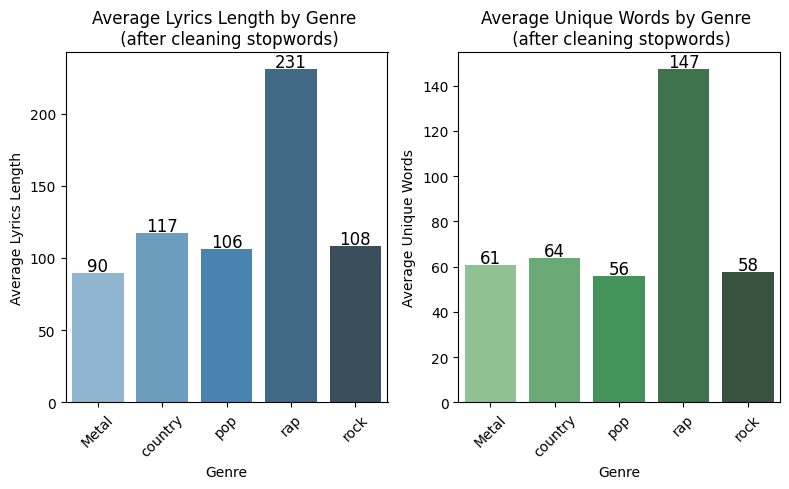

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 計算每首歌的歌詞長度（單詞數）
df_train['lyrics_length_af'] = df_train['cleaned_train_lyrics'].apply(lambda x: len(str(x).split()))

# 計算每首歌的獨特詞彙數量
df_train['unique_words_af'] = df_train['cleaned_train_lyrics'].apply(lambda x: len(set(str(x).split())))

# 按 genre 分組，計算平均歌詞長度與獨特詞彙數
genre_stats = df_train.groupby('genre')[['lyrics_length_af', 'unique_words_af']].mean().reset_index()

# 繪製兩張長條圖
fig, axes = plt.subplots(1, 2, figsize=(8, 5))  # 減小圖表的大小，讓兩個圖更寬鬆

# 歌詞長度統計
sns.barplot(x='genre', y='lyrics_length_af', data=genre_stats, ax=axes[0], palette='Blues_d')
axes[0].set_title('Average Lyrics Length by Genre \n (after cleaning stopwords)')
axes[0].set_ylabel('Average Lyrics Length')
axes[0].set_xlabel('Genre')
axes[0].tick_params(axis='x', rotation=45)

# 顯示每個條形圖上的數字
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black',
                     xytext=(0, 5), textcoords='offset points')  # 稍微向下移動

# 獨特詞彙數統計
sns.barplot(x='genre', y='unique_words_af', data=genre_stats, ax=axes[1], palette='Greens_d')
axes[1].set_title('Average Unique Words by Genre \n (after cleaning stopwords)')
axes[1].set_ylabel('Average Unique Words')
axes[1].set_xlabel('Genre')
axes[1].tick_params(axis='x', rotation=45)

# 顯示每個條形圖上的數字
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=12, color='black',
                     xytext=(0, 5), textcoords='offset points')  # 稍微向下移動

plt.tight_layout()  # 確保圖表不會重疊
plt.show()


In [ ]:
df_train

,Unnamed: 0,Lyric,genre,cleaned_train_lyrics,lyrics_length_bf,unique_words_bf,lyrics_length_af,unique_words_af
0,448760,search cost long search lose everybody help pe...,country,search cost long search lose everybodi help pe...,34,23,34,23
1,479107,"[Verse 1] Let me be the one to walk with you, ...",country,let one walk oh oh oh want someon talk anyth m...,172,68,81,32
2,486799,[Verse 1] All the times Ive wasted All the thi...,country,time ive wast thing thought knew think think b...,223,120,106,61
3,494185,"[Verse 1] Woodys Roundup Right here, evryday W...",country,woodi roundup right evryday woodi roundup come...,95,68,67,44
4,468639,[Verse] The Iowa weather was 13 below I had co...,country,iowa weather 13 come de moin radio show awok e...,207,149,106,90
...,...,...,...,...,...,...,...,...
4995,100507,"[Verse 1] The sun came out this morning, I was...",rock,sun came morn wide awak stumbl kitchen cut pie...,115,67,44,35
4996,54423,Slowly it starts to decay Softly the borders v...,Metal,slowli start decay softli border vanish enemi ...,112,57,69,41
4997,80575,Moonlight comes through the shades now Moonlig...,Metal,moonlight come shade moonlight come shade cut ...,138,81,66,46
4998,347633,"I am weak, but Thou art strong Jesus, keep me ...",pop,weak thou art strong jesu keep wrong ill satis...,154,75,84,38


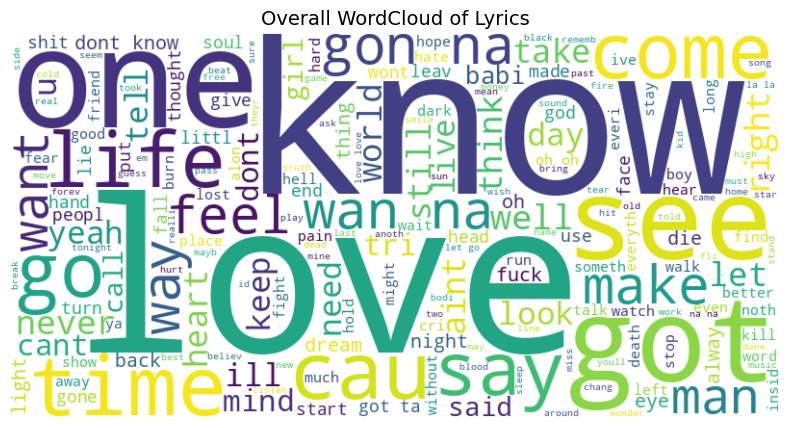

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1️⃣ 整個數據集的詞雲
all_text = " ".join(df_train['cleaned_train_lyrics'])  # 合併所有清理後的歌詞
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# 顯示詞雲
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 隱藏座標軸
plt.title("Overall WordCloud of Lyrics", fontsize=14)
plt.show()


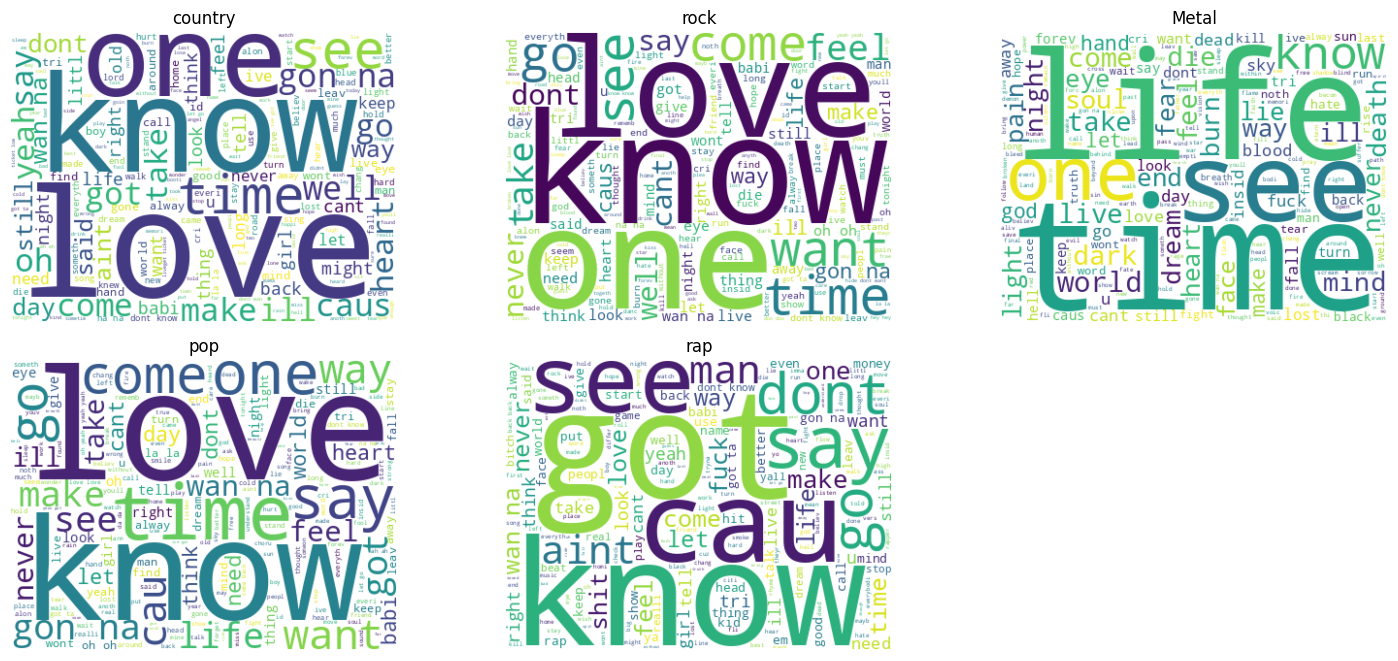

In [ ]:
# 2️⃣ 按 genre 繪製詞雲
genres = df_train['genre'].unique()  # 獲取所有不同的音樂類型

plt.figure(figsize=(15, 10))

for i, genre in enumerate(genres, 1):
    plt.subplot(3, 3, i)  # 創建子圖 (3行3列)
    genre_text = " ".join(df_train[df_train['genre'] == genre]['cleaned_train_lyrics'])
    wordcloud = WordCloud(width=400, height=300, background_color='white').generate(genre_text)

    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(genre)

plt.tight_layout()
plt.show()


# Bag of Words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# 先定義 BoW 模型
vectorizer_bow = CountVectorizer(max_features=5000)  # 取前 5000 個最常見的詞
X_train_bow = vectorizer_bow.fit_transform(df_train['cleaned_train_lyrics'])
X_test_bow = vectorizer_bow.transform(df_test['cleaned_test_lyrics'])

# 取得標籤
y_train = df_train['genre']
y_test = df_test['genre']


# 轉換為 DataFrame 方便查看
bow_df = pd.DataFrame(X_train_bow.toarray(), columns=vectorizer_bow.get_feature_names_out())
print("Bag of Words representation:")
print(bow_df.head())

Bag of Words representation:
   10  100  11  12  13  14  15  16  17  18  ...  youv  youyou  yuh  yup  zero  \
0   0    0   0   0   0   0   0   0   0   0  ...     0       0    0    0     0   
1   0    0   0   0   0   0   0   0   0   0  ...     0       0    0    0     0   
2   0    0   0   0   0   0   0   0   0   0  ...     0       0    0    0     0   
3   0    0   0   0   0   0   0   0   0   0  ...     0       0    0    0     0   
4   0    0   0   0   1   1   1   0   0   0  ...     0       0    0    0     0   

   zion  zip  zombi  zone  zoom  
0     0    0      0     0     0  
1     0    0      0     0     0  
2     0    0      0     0     0  
3     0    0      0     0     0  
4     0    0      0     0     0  

[5 rows x 5000 columns]


# TF - IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 轉換文本為 TF-IDF 特徵
vectorizer = TfidfVectorizer(max_features=5000)  # 取前 5000 個最常見的詞
X_train_tfidf = vectorizer.fit_transform(df_train['cleaned_train_lyrics'])
X_test_tfidf = vectorizer.transform(df_test['cleaned_test_lyrics'])

# 取得標籤
y_train = df_train['genre']
y_test = df_test['genre']

In [ ]:
vectorizer.get_feature_names_out()

array(['10', '100', '11', ..., 'zombi', 'zone', 'zoom'], dtype=object)

In [ ]:
len(vectorizer.get_feature_names_out())

5000

In [ ]:
vectorizer.vocabulary_

{'search': np.int64(3769),
 'cost': np.int64(954),
 'long': np.int64(2581),
 'lose': np.int64(2591),
 'everybodi': np.int64(1494),
 'help': np.int64(2078),
 'peopl': np.int64(3154),
 'kind': np.int64(2416),
 'save': np.int64(3727),
 'time': np.int64(4485),
 'come': np.int64(862),
 'think': np.int64(4434),
 'love': np.int64(2603),
 'discov': np.int64(1241),
 'train': np.int64(4547),
 'leav': np.int64(2497),
 'half': np.int64(1991),
 'past': np.int64(3120),
 'tomorrow': np.int64(4507),
 'weari': np.int64(4802),
 'stick': np.int64(4171),
 'line': np.int64(2549),
 'let': np.int64(2518),
 'one': np.int64(3021),
 'walk': np.int64(4767),
 'oh': np.int64(3002),
 'want': np.int64(4777),
 'someon': np.int64(4044),
 'talk': np.int64(4342),
 'anyth': np.int64(198),
 'make': np.int64(2646),
 'happi': np.int64(2010),
 'wan': np.int64(4774),
 'na': np.int64(2870),
 'darlin': np.int64(1089),
 'mean': np.int64(2702),
 'call': np.int64(628),
 'choos': np.int64(764),
 'partner': np.int64(3115),
 'choic':

# Word2Vec

In [ ]:
!pip install numpy==1.26.4

In [ ]:
!pip install gensim

In [ ]:
!pip uninstall pycocotools

Found existing installation: pycocotools 2.0.8
Uninstalling pycocotools-2.0.8:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/pycocotools-2.0.8.dist-info/*
    /usr/local/lib/python3.11/dist-packages/pycocotools/*
Proceed (Y/n)? y
  Successfully uninstalled pycocotools-2.0.8


In [ ]:
!pip install pycocotools==2.0.1

  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pycocotools
  Running setup.py clean for pycocotools
Failed to build pycocotools
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pycocotools)


In [ ]:
!pip install pycocotools --no-binary pycocotools

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pycocotools: filename=pycocotools-2.0.8-cp311-cp311-linux_x86_64.whl size=397838 sha256=c42ad78316813d724856938bd64c43e18c0d5cf80519d396155125bfb78d06bc
  Stored in directory: /root/.cache/pip/wheels/5f/95/99/5f112ddcd977ce30b9620fcf6f463e59d3d85d545cfb844042
Successfully built pycocotools


In [ ]:
import gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [ ]:
# 假設你已經清理過文本並有清理過的歌詞
# 使用 Tokenizer 分詞
def tokenize_lyrics(lyrics):
    return word_tokenize(lyrics.lower())  # 分詞並轉為小寫

# 將所有歌詞進行分詞
train_tokens = df_train['cleaned_train_lyrics'].apply(tokenize_lyrics)
test_tokens = df_test['cleaned_test_lyrics'].apply(tokenize_lyrics)

# 訓練 Word2Vec 模型
model_w2v = Word2Vec(sentences=train_tokens, vector_size=100, window=5, min_count=1, workers=4)

# 檢查一個詞的詞向量（示例：'love'）
word_vector = model_w2v.wv['love']
print(word_vector)


NameError: name 'Word2Vec' is not defined

In [ ]:


def get_average_word2vec(tokens, model, vector_size=100):
    # 去除不存在於模型中的詞
    valid_tokens = [token for token in tokens if token in model.wv]

    # 如果所有詞都不在詞彙表中，就返回全零向量
    if len(valid_tokens) == 0:
        return np.zeros(vector_size)

    # 將所有詞向量取平均
    vectors = np.array([model.wv[token] for token in valid_tokens])
    return vectors.mean(axis=0)

# 將訓練和測試集的歌詞轉換為向量
X_train_w2v = np.array([get_average_word2vec(tokens, model_w2v) for tokens in train_tokens])
X_test_w2v = np.array([get_average_word2vec(tokens, model_w2v) for tokens in test_tokens])


# Random Forest

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

## Random Forest with BOW

Random Forest Accuracy with BoW: 0.5420

Classification Report (BoW):
              precision    recall  f1-score   support

       Metal       0.65      0.80      0.71       113
     country       0.68      0.49      0.57        94
         pop       0.28      0.27      0.28        99
         rap       0.74      0.79      0.76        99
        rock       0.33      0.32      0.32        95

    accuracy                           0.54       500
   macro avg       0.53      0.53      0.53       500
weighted avg       0.54      0.54      0.53       500



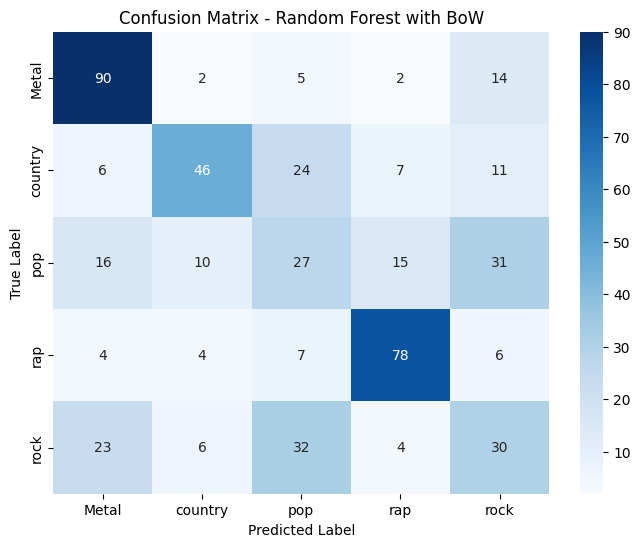

In [ ]:


# 訓練 Random Forest (BoW)
rf_bow = RandomForestClassifier(n_estimators=300, min_samples_split=5, max_depth=20, random_state=42, n_jobs=-1)
rf_bow.fit(X_train_bow, y_train)

# 預測 (BoW)
y_pred_rf_bow = rf_bow.predict(X_test_bow)

# 計算準確度 (BoW)
accuracy_bow = accuracy_score(y_test, y_pred_rf_bow)
print(f"Random Forest Accuracy with BoW: {accuracy_bow:.4f}")

# 計算精確度、召回率和 F1 分數
print("\nClassification Report (BoW):")
print(classification_report(y_test, y_pred_rf_bow))

# 繪製混淆矩陣 (BoW)
plt.figure(figsize=(8, 6))
cm_bow = confusion_matrix(y_test, y_pred_rf_bow)
sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Blues', xticklabels=rf_bow.classes_, yticklabels=rf_bow.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest with BoW")
plt.show()


## Random Forest with TF-IDF

Random Forest Accuracy with TF-IDF: 0.5640

Classification Report (TF-IDF):
              precision    recall  f1-score   support

       Metal       0.67      0.79      0.72       113
     country       0.65      0.56      0.60        94
         pop       0.31      0.31      0.31        99
         rap       0.78      0.77      0.78        99
        rock       0.37      0.35      0.36        95

    accuracy                           0.56       500
   macro avg       0.56      0.56      0.55       500
weighted avg       0.56      0.56      0.56       500



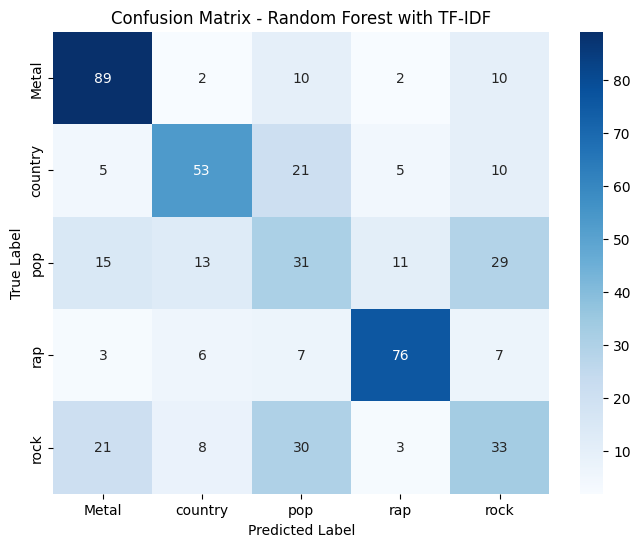

In [ ]:
# 訓練 Random Forest 模型
rf_model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)  # 使用 300 棵樹
rf_model.fit(X_train_tfidf, y_train)

# 預測
y_pred_rf_tfidf = rf_model.predict(X_test_tfidf)

# 計算準確度
accuracy_tfidf = accuracy_score(y_test, y_pred_rf_tfidf)
print(f"Random Forest Accuracy with TF-IDF: {accuracy_tfidf:.4f}")

# 計算混淆矩陣
cm = confusion_matrix(y_test, y_pred_rf_tfidf)

# 計算精確度、召回率和 F1 分數
print("\nClassification Report (TF-IDF):")
print(classification_report(y_test, y_pred_rf_tfidf))

# 繪製混淆矩陣
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest with TF-IDF")
plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# # 轉換文本為 TF-IDF 特徵
# vectorizer = TfidfVectorizer()
# X_train_tfidf = vectorizer.fit_transform(df_train['cleaned_train_lyrics'])
# X_test_tfidf = vectorizer.transform(df_test['cleaned_test_lyrics'])

# # 取得標籤
# y_train = df_train['genre']
# y_test = df_test['genre']

# # 定義要調整的超參數範圍
# param_grid = {
#     'n_estimators': [100, 300, 500, 700],  # 樹的數量
#     'max_depth': [10, 20, 30, None],       # 樹的最大深度
#     'min_samples_split': [2, 5, 10],       # 分裂節點的最小樣本數
#     'min_samples_leaf': [1, 2, 4]          # 葉節點的最小樣本數
# }

# # 使用 RandomizedSearchCV 進行超參數搜尋
# random_search = RandomizedSearchCV(
#     RandomForestClassifier(random_state=42, n_jobs=-1),
#     param_grid,
#     n_iter=10,  # 測試 10 組不同參數組合
#     cv=3,       # 3-fold 交叉驗證
#     verbose=2,
#     random_state=42,
#     n_jobs=-1   # 使用所有 CPU 核心加速
# )

# random_search.fit(X_train_tfidf, y_train)

# # 印出最佳參數
# print("Best Parameters:", random_search.best_params_)

# # 用最佳參數訓練 Random Forest
# best_rf_model = RandomForestClassifier(
#     n_estimators=random_search.best_params_['n_estimators'],
#     max_depth=random_search.best_params_['max_depth'],
#     min_samples_split=random_search.best_params_['min_samples_split'],
#     min_samples_leaf=random_search.best_params_['min_samples_leaf'],
#     random_state=42,
#     n_jobs=-1
# )

# best_rf_model.fit(X_train_tfidf, y_train)

# # 預測
# y_pred = best_rf_model.predict(X_test_tfidf)

# # 計算準確度
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Random Forest Accuracy (TF-IDF): {accuracy:.4f}")

# # 顯示分類報告
# print("\nClassification Report:")
# print(classification_report(y_test, y_pred))

# # 繪製混淆矩陣
# plt.figure(figsize=(8, 6))
# cm = confusion_matrix(y_test, y_pred)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_rf_model.classes_, yticklabels=best_rf_model.classes_)
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix")
# plt.show()


## Random Forest with Word2Vec

Random Forest (Word2Vec) Accuracy: 0.5320

Classification Report (Word2Vec):
              precision    recall  f1-score   support

       Metal       0.71      0.70      0.70       113
     country       0.53      0.63      0.57        94
         pop       0.31      0.28      0.30        99
         rap       0.67      0.70      0.68        99
        rock       0.37      0.33      0.35        95

    accuracy                           0.53       500
   macro avg       0.52      0.53      0.52       500
weighted avg       0.52      0.53      0.53       500



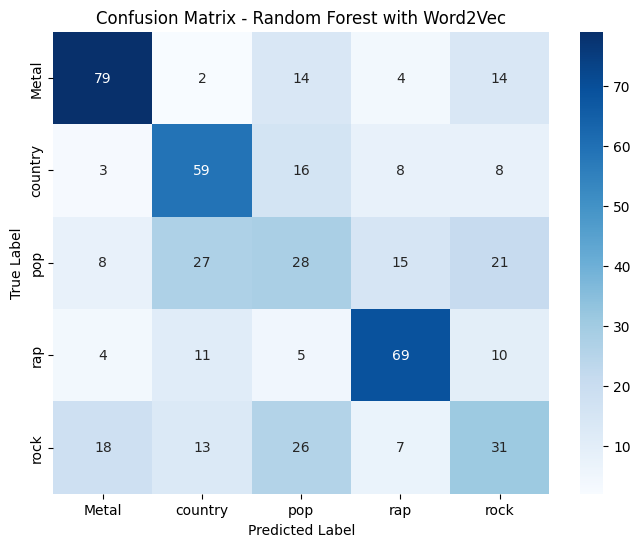

In [ ]:
# 訓練 Random Forest 模型
rf_model_w2v = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_w2v.fit(X_train_w2v, y_train)

# 預測
y_pred_rf_w2v = rf_model_w2v.predict(X_test_w2v)

# 計算準確度
accuracy_w2v = accuracy_score(y_test, y_pred_rf_w2v)
print(f"Random Forest (Word2Vec) Accuracy: {accuracy_w2v:.4f}")

# 顯示分類報告
print("\nClassification Report (Word2Vec):")
print(classification_report(y_test, y_pred_rf_w2v))

# 繪製混淆矩陣
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf_w2v)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model_w2v.classes_, yticklabels=rf_model_w2v.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest with Word2Vec")

plt.show()


## All Model's Accuracy

In [ ]:
print(f"Random Forest (BoW) Accuracy: {accuracy_bow:.4f}")
print(f"Random Forest (TF-IDF) Accuracy: {accuracy_tfidf:.4f}")
print(f"Random Forest (Word2Vec) Accuracy: {accuracy_w2v:.4f}")

# Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

##  Logistic Regression with BOW

BoW + Logistic Regression Accuracy: 0.4760


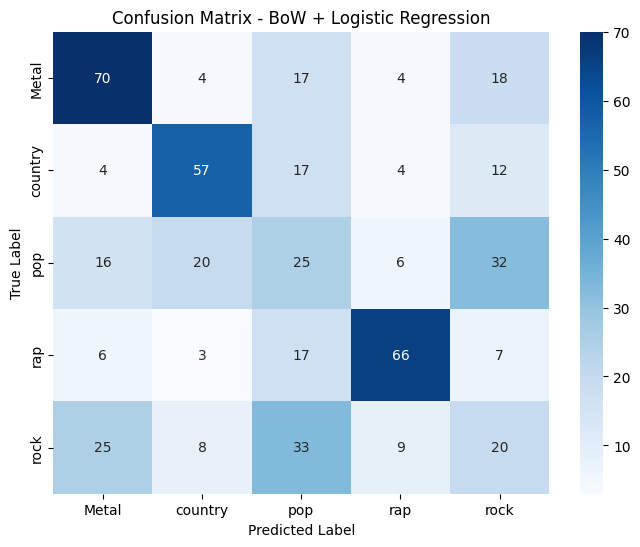

In [ ]:
lr_bow = LogisticRegression(max_iter=200, random_state=42)
lr_bow.fit(X_train_bow, y_train)
y_pred_bow_lr = lr_bow.predict(X_test_bow)


# 計算準確率
accuracy_bow_lr = accuracy_score(y_test, y_pred_bow_lr)

print(f"BoW + Logistic Regression Accuracy: {accuracy_bow_lr:.4f}")


# 繪製混淆矩陣
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=lr_bow.classes_, yticklabels=lr_bow.classes_)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

plot_confusion_matrix(y_test, y_pred_bow_lr, "BoW + Logistic Regression")

##  Logistic Regression with TF-IDF

TF-IDF + Logistic Regression Accuracy: 0.5660


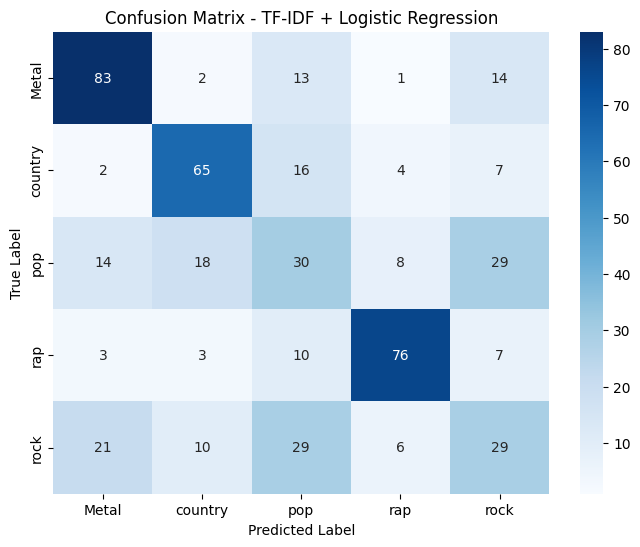

In [ ]:
lr_tfidf = LogisticRegression(max_iter=200, random_state=42)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf_lr = lr_tfidf.predict(X_test_tfidf)

# 計算準確率
accuracy_tfidf_lr = accuracy_score(y_test, y_pred_tfidf_lr)

print(f"TF-IDF + Logistic Regression Accuracy: {accuracy_tfidf_lr:.4f}")

# 繪製混淆矩陣
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=lr_bow.classes_, yticklabels=lr_bow.classes_)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

plot_confusion_matrix(y_test, y_pred_tfidf_lr, "TF-IDF + Logistic Regression")

##  Logistic Regression with Word2Vec

Logistic Regression (Word2Vec) Accuracy: 0.5260

Classification Report (Logistic Regression - Word2Vec):
              precision    recall  f1-score   support

       Metal       0.65      0.71      0.68       113
     country       0.61      0.63      0.62        94
         pop       0.32      0.31      0.32        99
         rap       0.64      0.68      0.66        99
        rock       0.32      0.27      0.30        95

    accuracy                           0.53       500
   macro avg       0.51      0.52      0.51       500
weighted avg       0.52      0.53      0.52       500



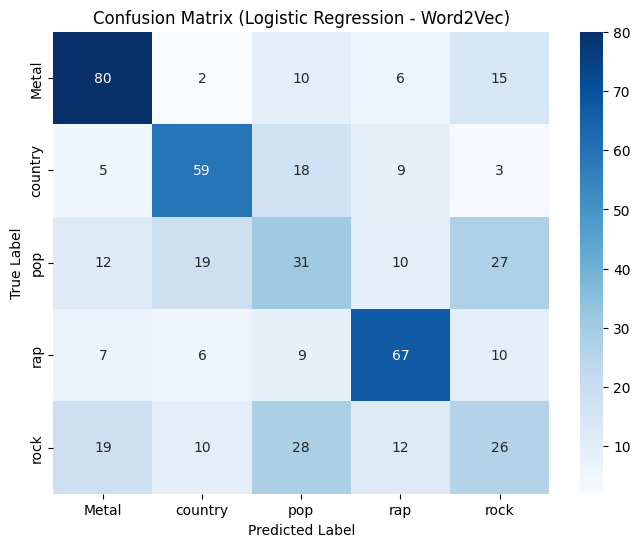

In [ ]:
# 訓練 Logistic Regression 模型
lr_model_w2v = LogisticRegression(max_iter=1000, random_state=42)
lr_model_w2v.fit(X_train_w2v, y_train)

# 預測
y_pred_lr_w2v = lr_model_w2v.predict(X_test_w2v)

# 計算準確度
accuracy_lr_w2v = accuracy_score(y_test, y_pred_lr_w2v)
print(f"Logistic Regression (Word2Vec) Accuracy: {accuracy_lr_w2v:.4f}")

# 顯示分類報告
print("\nClassification Report (Logistic Regression - Word2Vec):")
print(classification_report(y_test, y_pred_lr_w2v))

# 繪製混淆矩陣
plt.figure(figsize=(8, 6))
cm_lr = confusion_matrix(y_test, y_pred_lr_w2v)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=lr_model_w2v.classes_, yticklabels=lr_model_w2v.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Logistic Regression - Word2Vec)")
plt.show()


# Naïve Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

## Naïve Bayes with BOW



BoW + Naïve Bayes Accuracy: 0.5380

Classification Report (BoW):
              precision    recall  f1-score   support

       Metal       0.67      0.73      0.70       113
     country       0.62      0.67      0.64        94
         pop       0.31      0.35      0.33        99
         rap       0.75      0.73      0.74        99
        rock       0.24      0.17      0.20        95

    accuracy                           0.54       500
   macro avg       0.52      0.53      0.52       500
weighted avg       0.52      0.54      0.53       500



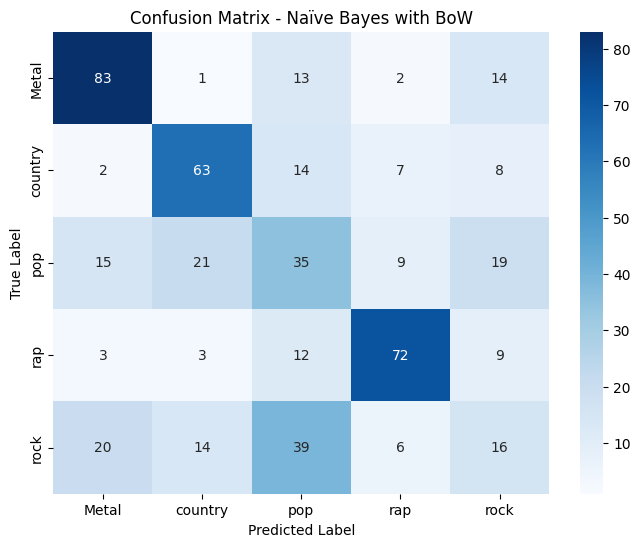

In [ ]:
# 訓練 BoW + Naïve Bayes
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_bow_nb = nb_bow.predict(X_test_bow)


# 計算準確率
accuracy_bow_nb = accuracy_score(y_test, y_pred_bow_nb)
print(f"BoW + Naïve Bayes Accuracy: {accuracy_bow_nb:.4f}")

# 計算精確度、召回率和 F1 分數
print("\nClassification Report (BoW):")
print(classification_report(y_test, y_pred_bow_nb))

# 繪製混淆矩陣
plot_confusion_matrix(y_test, y_pred_bow_nb, "Naïve Bayes with BoW")


## Naïve Bayes with TF-IDF


TF-IDF + Naïve Bayes Accuracy: 0.5420

Classification Report (TF-IDF):
              precision    recall  f1-score   support

       Metal       0.72      0.72      0.72       113
     country       0.58      0.69      0.63        94
         pop       0.37      0.22      0.28        99
         rap       0.55      0.89      0.68        99
        rock       0.27      0.16      0.20        95

    accuracy                           0.54       500
   macro avg       0.50      0.54      0.50       500
weighted avg       0.51      0.54      0.51       500



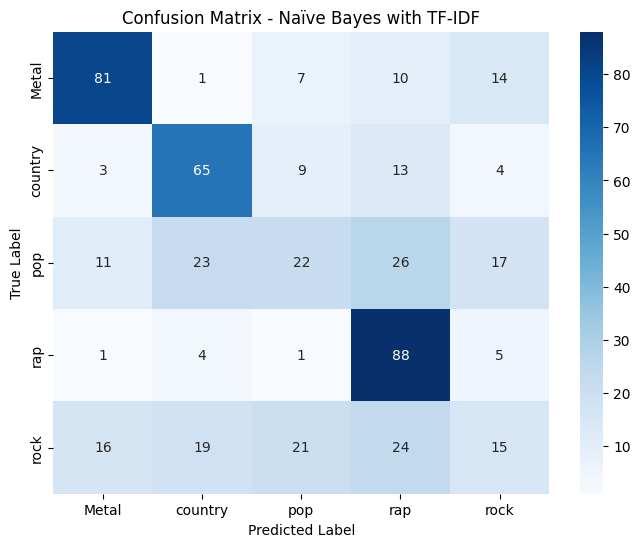

In [ ]:
# 訓練 TF-IDF + Naïve Bayes
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf_nb = nb_tfidf.predict(X_test_tfidf)

accuracy_tfidf_nb = accuracy_score(y_test, y_pred_tfidf_nb)
print(f"TF-IDF + Naïve Bayes Accuracy: {accuracy_tfidf_nb:.4f}")

# 計算精確度、召回率和 F1 分數
print("\nClassification Report (TF-IDF):")
print(classification_report(y_test, y_pred_tfidf_nb))

plot_confusion_matrix(y_test, y_pred_tfidf_nb, "Naïve Bayes with TF-IDF")

## Naïve Bayes with Word2Vec

Gaussian Naïve Bayes Accuracy: 0.548

Classification Report (Word2Vec):
              precision    recall  f1-score   support

       Metal       0.59      0.71      0.65       113
     country       0.43      0.54      0.48        94
         pop       0.32      0.26      0.29        99
         rap       0.51      0.72      0.59        99
        rock       0.25      0.06      0.10        95

    accuracy                           0.47       500
   macro avg       0.42      0.46      0.42       500
weighted avg       0.43      0.47      0.43       500



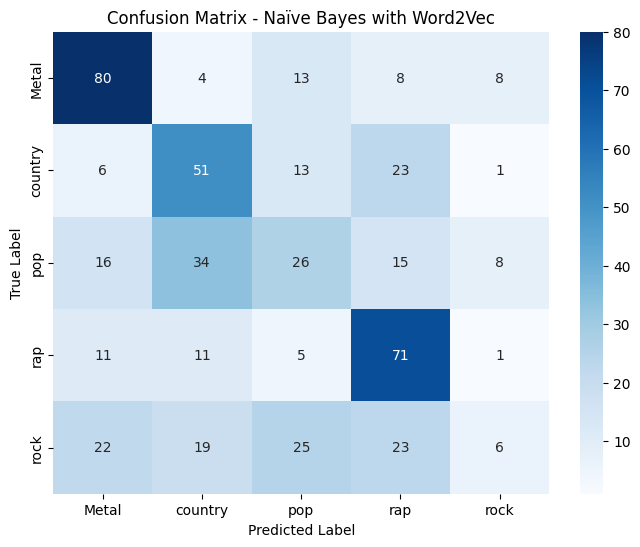

In [ ]:
# 建立 Gaussian Naïve Bayes 模型
gnb = GaussianNB()

# 訓練模型
gnb.fit(X_train_w2v, y_train)

# 進行預測
y_pred_w2v_nb = gnb.predict(X_test_w2v)

# 計算準確率
accuracy_w2v_nb = accuracy_score(y_test, y_pred)
print("Gaussian Naïve Bayes Accuracy:", accuracy_w2v_nb)

# 計算精確度、召回率和 F1 分數
print("\nClassification Report (Word2Vec):")
print(classification_report(y_test, y_pred_w2v_nb))

plot_confusion_matrix(y_test, y_pred_w2v_nb, "Naïve Bayes with Word2Vec")

# XGBoost

In [ ]:
pip install xgboost scikit-learn bayesian-optimization


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from bayes_opt import BayesianOptimization
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder

In [ ]:
# 資料重新編碼
# 定義手動映射
genre_mapping = {
    "country": 0,
    "rap": 1,
    "Metal": 2,
    "rock": 3,
    "pop": 4
}

# 將 genre 轉換為數字編碼
df_train['genre_encoded'] = df_train['genre'].map(genre_mapping)
df_test['genre_encoded'] = df_test['genre'].map(genre_mapping)

# 確認編碼結果
print(df_train[['genre', 'genre_encoded']].drop_duplicates())
print(df_test[['genre', 'genre_encoded']].drop_duplicates())

     genre  genre_encoded
0  country              0
5     rock              3
6    Metal              2
7      pop              4
8      rap              1
      genre  genre_encoded
0      rock              3
1   country              0
2       pop              4
3       rap              1
11    Metal              2


## XGBoost Bayes with BOW

In [ ]:
# 取得標籤
y_train_XGBoost = df_train['genre_encoded']
y_test_XGBoost = df_test['genre_encoded']

XGBoost Accuracy with BOW: 0.5860

Classification Report (XGBoost with BOW):
              precision    recall  f1-score   support

           0       0.62      0.73      0.67       113
           1       0.73      0.59      0.65        94
           2       0.40      0.44      0.42        99
           3       0.88      0.71      0.78        99
           4       0.40      0.43      0.42        95

    accuracy                           0.59       500
   macro avg       0.61      0.58      0.59       500
weighted avg       0.61      0.59      0.59       500



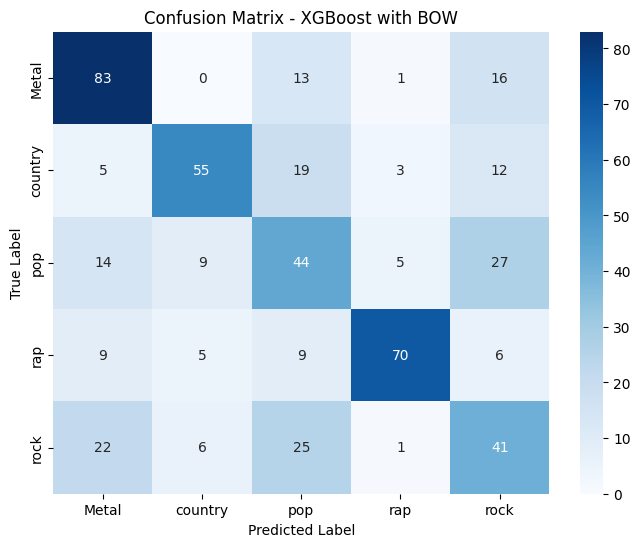

In [ ]:
# 初始化 XGBoost 分類器
model = xgb.XGBClassifier(
    objective='multi:softmax',  # 假設是多分類問題
    random_state=42,
    n_jobs=-1,
    max_depth=4,  # 默認參數
    learning_rate=0.026939147064084047,  # 默認參數
    n_estimators=441,  # 默認參數
    min_child_weight=6  # 默認參數
)
genre_labels = ['Metal', 'country', 'pop', 'rap', 'rock']

# {'target': 0.588, 'params': {'learning_rate': 0.026939147064084047, 'max_depth': 4.545923222278887,
# 'min_child_weight': 5.953514774426425, 'n_estimators': 441.3281100194241}}

# Manually encode labels using LabelEncoder
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(df_train['genre'])
y_test_encoded = label_encoder.transform(df_test['genre'])

# Train the model
model.fit(X_train_bow, y_train_encoded)

# Predict the test set
y_pred_best = model.predict(X_test_bow)

# Calculate accuracy and classification metrics
accuracy_best = accuracy_score(y_test_encoded, y_pred_best)
print(f"XGBoost Accuracy with BOW: {accuracy_best:.4f}")

# Print classification report
print("\nClassification Report (XGBoost with BOW):")
print(classification_report(y_test_encoded, y_pred_best))

# Now plot confusion matrix with correct class labels
genre_labels = ['Metal', 'country', 'pop', 'rap', 'rock']
plt.figure(figsize=(8, 6))
cm_best = confusion_matrix(y_test_encoded, y_pred_best)

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=genre_labels, yticklabels=genre_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost with BOW")
plt.show()

## XGBoost Bayes with TF-IDF

XGBoost Accuracy with TF-IDF: 0.5780

Classification Report (XGBoost with TF-IDF):
              precision    recall  f1-score   support

           0       0.67      0.73      0.69       113
           1       0.70      0.53      0.61        94
           2       0.39      0.42      0.40        99
           3       0.86      0.73      0.79        99
           4       0.38      0.45      0.41        95

    accuracy                           0.58       500
   macro avg       0.60      0.57      0.58       500
weighted avg       0.60      0.58      0.59       500



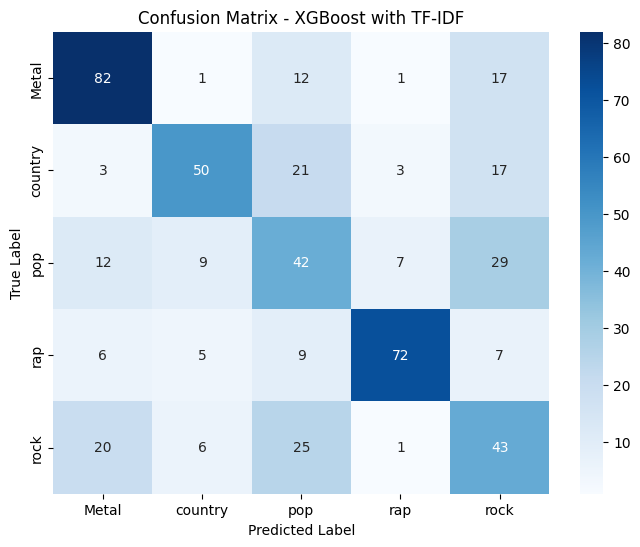

In [ ]:
# 初始化 XGBoost 分類器
model = xgb.XGBClassifier(
    objective='multi:softmax',  # 假設是多分類問題
    random_state=42,
    n_jobs=-1,
    max_depth=4,  # 默認參數
    learning_rate=0.026939147064084047,  # 默認參數
    n_estimators=441,  # 默認參數
    min_child_weight=6  # 默認參數
)

# 手動編碼標籤
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(df_train['genre'])
y_test_encoded = label_encoder.transform(df_test['genre'])

# 訓練模型
model.fit(X_train_tfidf, y_train_encoded)

# 預測測試集
y_pred_best = model.predict(X_test_tfidf)

# 計算準確度和分類報告
accuracy_best = accuracy_score(y_test_encoded, y_pred_best)
print(f"XGBoost Accuracy with TF-IDF: {accuracy_best:.4f}")

# 打印分類報告
print("\nClassification Report (XGBoost with TF-IDF):")
print(classification_report(y_test_encoded, y_pred_best))

# 現在繪製混淆矩陣
genre_labels = ['Metal', 'country', 'pop', 'rap', 'rock']
plt.figure(figsize=(8, 6))
cm_best = confusion_matrix(y_test_encoded, y_pred_best)

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=genre_labels, yticklabels=genre_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost with TF-IDF")
plt.show()

## XGBoost Bayes with Word2Vec

XGBoost Accuracy with TF-IDF: 0.5280

Classification Report (XGBoost with TF-IDF):
              precision    recall  f1-score   support

           0       0.66      0.73      0.69       113
           1       0.51      0.66      0.58        94
           2       0.34      0.25      0.29        99
           3       0.64      0.69      0.66        99
           4       0.36      0.28      0.32        95

    accuracy                           0.53       500
   macro avg       0.50      0.52      0.51       500
weighted avg       0.51      0.53      0.51       500



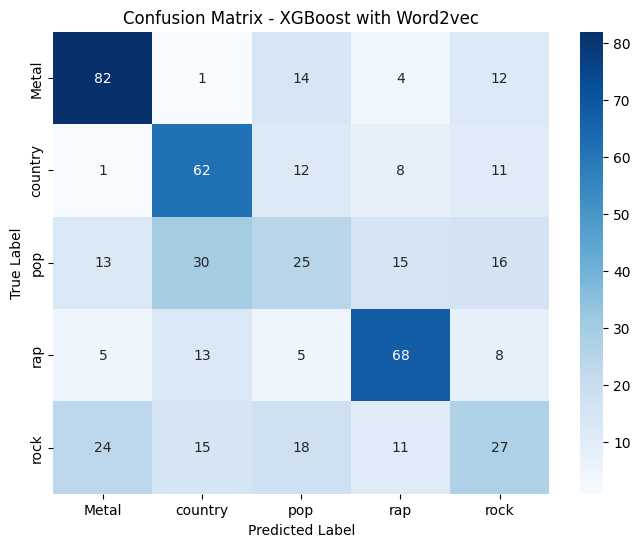

In [ ]:
# 初始化 XGBoost 分類器
model = xgb.XGBClassifier(
    objective='multi:softmax',  # 假設是多分類問題
    random_state=42,
    n_jobs=-1,
    max_depth=4,  # 默認參數
    learning_rate=0.026939147064084047,  # 默認參數
    n_estimators=441,  # 默認參數
    min_child_weight=6  # 默認參數
)

# 手動編碼標籤
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(df_train['genre'])
y_test_encoded = label_encoder.transform(df_test['genre'])

# 訓練模型
model.fit(X_train_w2v, y_train_encoded)

# 預測測試集
y_pred_best = model.predict(X_test_w2v)

# 計算準確度和分類報告
accuracy_best = accuracy_score(y_test_encoded, y_pred_best)
print(f"XGBoost Accuracy with TF-IDF: {accuracy_best:.4f}")

# 打印分類報告
print("\nClassification Report (XGBoost with TF-IDF):")
print(classification_report(y_test_encoded, y_pred_best))

# 現在繪製混淆矩陣
genre_labels = ['Metal', 'country', 'pop', 'rap', 'rock']
plt.figure(figsize=(8, 6))
cm_best = confusion_matrix(y_test_encoded, y_pred_best)

sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=genre_labels, yticklabels=genre_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost with Word2vec")
plt.show()